# Q8 - Classification
Classification is part of the supervised learning category of machine learning, together with regression. For classification, we have some known classes that we want to distribute data points correctly into. The classes are discrete, where regression is continious. 

### Focus c: Linear and non-linear decision boundaries, including SVM
For linear classification, we assume a linear boundary between classes. With binary classification for example, we assume we can split everything into two corresponding to the labelled classes. This is for example what we do with logistic regression, where the sigmoid function defines the linear decision boundary. The sigmoid function lifts the dimensionality of the data, such that the new dimension is the probability of the data belonging to the positive class. (binary). 

What can we do when the decision boundary is not linear? For example in this exercise, where class 2 surrounds class 1. Looking at this, we could use a cicle function or a polynomial kernel, to lift it to a higher dimension and there find a linear boundary. In this exercise, we choose a non-linear decision bounary, a circle. 

Another solution is a non-linear transformation to polar coordinates. It stays in 2d, but the features are no longer x and y cardinal values, but radius and angle from origin. This allows us to make a linear decision boundary, and perform linear classification. 

Support vector machine is a method that can be used for both linear and non-linear classes. This uses the same approach as I mentioned before about how we can create a linear boundary for data that looks non-linear. We can lift it to a higher dimension, such as using a polynomial kernel. After transforming the data and increasing dimensionality, it finds a support vector classifier with the maximum margins. Using cross validation, it does it multiple times, using different higher dimensions to find the best possible boundary. 

# Non-linear decision boundary
The following exercise experiments with a dataset (see visualization in the cell below), where a linear model cannot seperate the different classes in the data.

<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#linear">Task 1: Non-linear decision boundary</a>
            </li>
            <li>
            <a href="#manual">Task 2: Circular boundary</a>
            </li>
            <li>
            <a href="#predict2">Task 3: Predictions for non-linear data</a>
            </li>
            <li>
            <a href="#predict53">Task 4: Predictions for non-linear data</a>
            </li>
            <li>
            <a href="#polar">Task 5: Polar coordinates</a>
            </li>
        </ul>
    </div>
</article>

Run the cell below to load libraries and functions and construct the dataset:


In [3]:
import numpy as np  # numeriacal computing
import matplotlib.pyplot as plt  # plotting core


def accuracy(predictions,targets):
    """
    :param predictions: 1D-array of predicted classes for the data.
    :param targets: 1D-array of actual classes for the data.
     
    :return: fraction of correctly predicted points (num_correct/num_points).
    """

    acc = np.sum(predictions == targets)/len(predictions)
    return acc

### Data generation
q1 = np.random.multivariate_normal([0, 0], [[.5, 0], [0, .5]], 400)

t = np.linspace(0, 2 * np.pi, 400)  ##  
q2 = np.array([(3 + q1[:, 0]) * np.sin(t), (3 + q1[:, 1]) * np.cos(t)]).T

The data of the two classes (`class 1`
 and `class 2`
) are stored in the variables `q1`
 and `q2`
, respectively. The following cell visualize the dataset of the two classes. `class 1`
 is labelled with 0s and `class 2`
 with 1s.


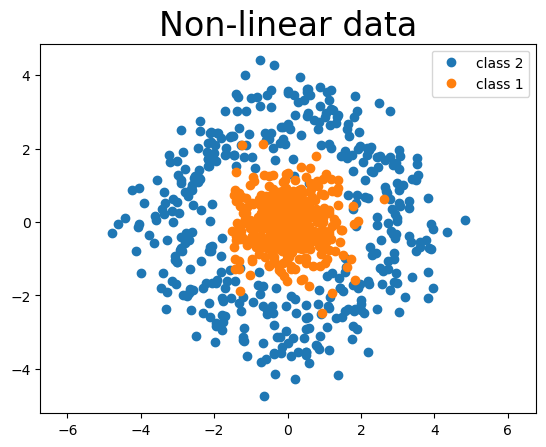

In [4]:
fig, ax = plt.subplots()
ax.plot(q2[:, 0], q2[:, 1], "o", label='class 2')
ax.plot(q1[:, 0], q1[:, 1], "o", label='class 1')

plt.title("Non-linear data", fontsize=24)
ax.axis('equal')
plt.legend()
plt.show()


---
**Task 1 (easy): Non-linear decision boundary👩‍💻💡**
The graph below shows how linear model performs on the current dataset (see last week
 ).
1. Using your observations about linear classification models, explain whether a linear classifier is an appropriate solution for the current data.
2. Which other models might provide a better fit to this dataset?


---

In [5]:
#1. a linear classification model would not suit this problem. 
#2. a circle function might be good. Or introducing a 3rd dimension, with a polynomial kernel. 


---
**Task 2 (easy): Circular boundary💡**
In this task the prediction function $f_w(x)$ is defined as a circular boundary centered in $[0,0]^T$.
1. Run the cell below to plot the circular boundary and the data points.
2. Change the radius of the decision boundary and determine which radius seems to best separate the classes?
3. Change the decision boundary and investigate how this affects the balance between false positives and false negatives? How does an overly large or small radius affect false positives and false negatives respectively? 


**Understanding the code**
The parametric equation of a circle, ([described in detail here](https://mathopenref.com/coordparamcircle.html)
) is given by:

$$
x = r \cos(t) \\
y = r \sin(t)
$$
where  $r$  is the radius of the circle and  $t$  represents angles (in radians) that range from  0  to  $2\pi$ .


---

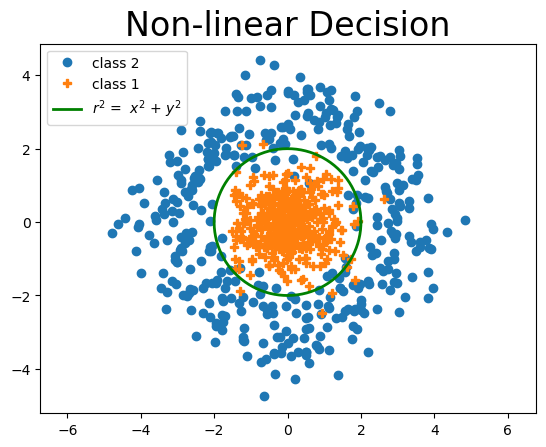

In [6]:
def circle_boundary(t, radius):
    """
    :param t: angle data points of the circle. 
    :param radius: radius of the circle
    :return: (x-values,y-values) of the circle points .
    """
    return (radius * np.cos(t), radius * np.sin(t))


fig, ax = plt.subplots()
ax.plot(q2[:, 0], q2[:, 1], "o", label='class 2')
ax.plot(q1[:, 0], q1[:, 1], "P", label='class 1')

t = np.linspace(0, 2 * np.pi, 400)  ### linspace of angles.
r = 2  # radius
x_c, y_c = circle_boundary(t, r)

ax.plot(x_c, y_c, "g",linewidth=2, label=r'$r^2$ =  $x^2$ + $y^2$')
plt.title("Non-linear Decision", fontsize=24)
ax.axis('equal')
plt.legend()
plt.show()

In [7]:
# write your reflections here
# if class 1 is the positive, and we want to make sure we have no false negatives, then the radius for the boundary should be large. 
#   This way we are sure that we catch all of the true positives. 
# 
# It can also be that we just don't want any false positives. 
#   Then we should make a boundary smaller


---
**Task 3 (easy): Predictions for non-linear data👩‍💻**
This task is about using the circular decision boundary (parametrized by $r$)  to classify points. Since the points are centered in $[0,0]^T$ the classification function should just check whether the distance of the point to the center is smaller or greater than $r$. That is  $\sqrt{x^2 + y^2}≤r$, or equivalently,  $x^2 + y^2 ≤ r^2$.
The prediction function is given by $f_w(x)= x^2 + y^2 - r^2$ as the decision function must fulfill $f_w(x) = 0$ on the decision boundary
1. Comple the `predict_circle`
 function. The function should take radius and data ($(x, y)$ coordinates) as inputs and return an array of predicted classes based on the decision function, e.g.:    - -1 for points where  $x^2 + y^2 < r^2$  (inside the circle).
    - 1 for points where  $x^2 + y^2 > r^2$  (outside the circle).


2. Use the `accuracy`
 function to get the fraction of correctly predicted data points.


---

In [8]:
def predict_circle(radius, data):
    """
    :param radius: radius of the circular decision boundary.
    :param data: Array containing data points to classify.
    
    :return: Array of predictions (-1 for inside, 1 for outside the boundary).
    """
    return np.sign(data[:,0]**2 + data[:,1]**2 - radius**2)

r = 2
# Calculate accuracy here
pred_1 = predict_circle(r, q1)
pred_2 = predict_circle(r, q2)
acc_1 = accuracy(pred_1, -np.ones(len(pred_1)))
acc_2 = accuracy(pred_2, np.ones(len(pred_2)))


print(f'A circular decision boundary with radius: {r:1}, has an accuracy of: {(acc_1+acc_2)/2:.3f}')

A circular decision boundary with radius: 2, has an accuracy of: 0.968



---
**Task 4 (easy): Predictions for non-linear data💡📽️**
In the cell below, reflect on:
1. Visually what is the optimal choice for radius of the classifier?
2. Try 10 different radius values and identify which one results in the highest accuracy.
3. How does the type of the data influence the choice of "optimality"? 


---

In [9]:
# write your reflections here
#1. visually, I chose radius = 2

#2. The radius 2 has the highest accuracy, of 97.1%

#3. When just looking at overall accuracy, we don't really weigh false postives or false negatives higher than the other. 
#   For some data, like predicting diseases, we might want to focus on minimising false negatives. 
#   We would rather have false positives in this case. 
#   Tradeoff between recall and precision

## Non-linear transformations to the data using polar coordinates
This task is about applying non-linear transformations to facilitate the use of a linear classifier. A point can be represented either by its Cartesian coordinates,  $x$, $y$ , or equivalently by its polar coordinates, defined by an angle $\theta$ and distance $r$ from the origin as shown in [Figure 1](#tensorboard). 
<div class="has-text-centered">
<figure class="image is-inline-block" id="tensorboard">

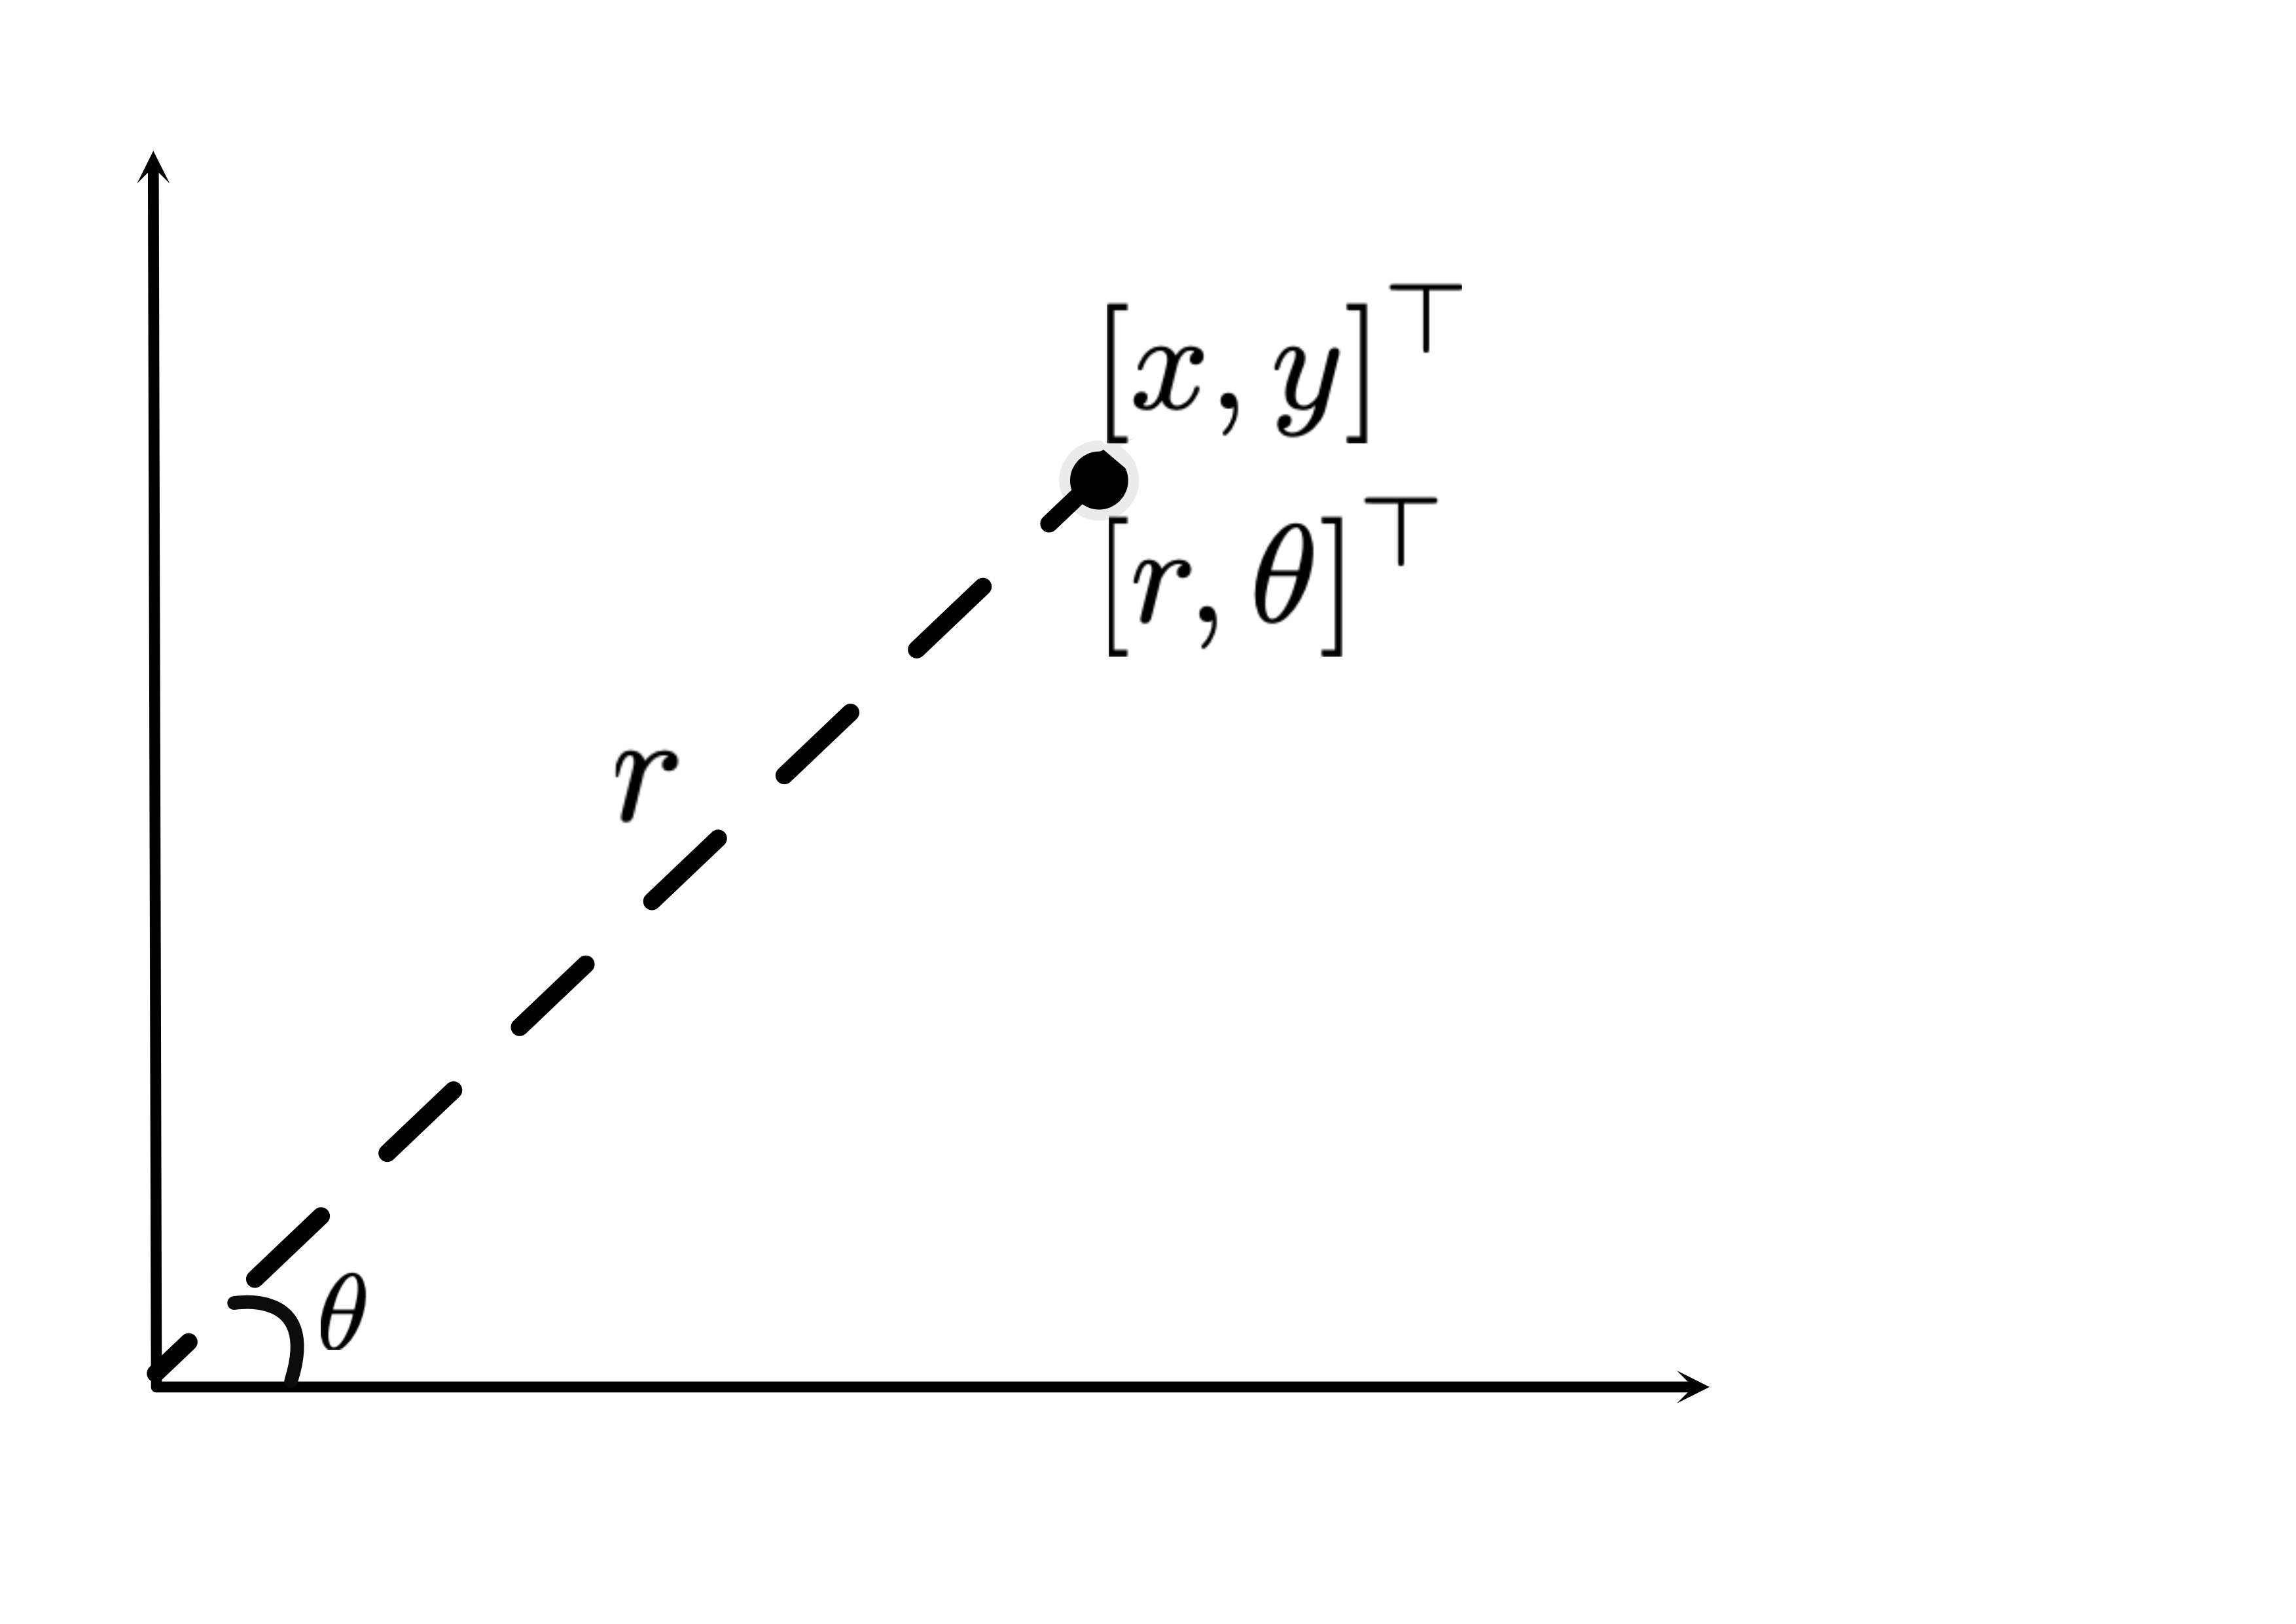

<figcaption class="figure-caption has-text-centered">Figure 1</figcaption>
</figure>
</div>

---
**Task 5 (easy): Polar coordinates👩‍💻💡📽️**
The function `map_to_polar_separable`
 below non-linearly transforms each point $(x, y)$ to its polar coordinates $(r, \theta)$.
1. Run the cell below to visualize the dataset in polar coordinates. 
2. Compare the distribution of the data in polar versus Cartesian coordinates. What key differences do you observe?
3. Does transforming the data to polar coordinates make it easier to separate the classes with a linear classifier? How does this transformation change the classification problem?
4. Which parameter separates the classes?
5. Reflect on how pre-processing of data can change the models used for classification.
6. How is the non-linear transformation to polar coordinates different from using kernels for classification?


---

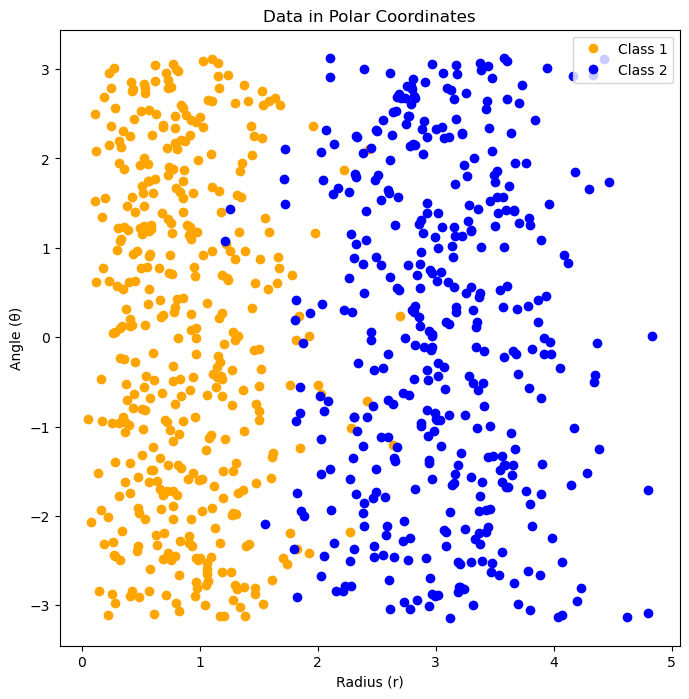

In [10]:
def map_to_polar_separable(data):
    """
    Maps circular data centered at (0, 0) to polar coordinates (r, theta),
    making the data linearly separable by radius (r).
 
    Parameters:
    - data: A numpy array of shape (N, 2) where each row is a point (x, y).
 
    Returns:
    - polar_data: A numpy array of shape (N, 2) where each row is (r, theta),
      where r is the radial distance and theta is the angle in radians.
    """
    # Convert to polar coordinates
    r = np.sqrt(data[:, 0]**2 + data[:, 1]**2)  # Radial distance
    theta = np.arctan2(data[:, 1], data[:, 0])  # Angle in radians
   
    # Stack r and theta to form polar data
    polar_data = np.column_stack((r, theta))
   
    return polar_data
   
data = np.vstack([q1, q2])  
polar_data=map_to_polar_separable(data)

# Split polar data into classes
polar_q1 = polar_data[:len(q1)]
polar_q2 = polar_data[len(q1):]

# Plot data in polar coordinates
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(polar_q1[:, 0], polar_q1[:, 1], "o", label="Class 1", color="orange")
ax.plot(polar_q2[:, 0], polar_q2[:, 1], "o", label="Class 2", color="blue")
plt.xlabel("Radius (r)")
plt.ylabel("Angle (θ)")
plt.title("Data in Polar Coordinates")
plt.legend()
plt.show()

In [0]:
# Write reflections here
#2. The key difference is that when using radius as x-value and angle as y-value, we get a natural separation of the two classes in 2d. 
#   I think the two features should be flipped, 
#   because it makes sense that we have points on all angles of the, but the yellow have a shorter radial distance from 0,0 than the blue points. 
#3. It makes sense to use polar coordinates because we now get a separator in 2d space to use. 
#4. In the graph, it looks like the angle, but I think it should be the radius that actually separates the classes? 
#5. With this pre-processing with transforming to polar coordinates, we can then use linear least squares to find a linear decision boundary
#6. It's different from using kernels, because we stay in 2d, not lifting to higher dimensions. 